# End-to-End Sales Forecasting & Demand Intelligence System

### XYlofy AI Internship – Week 3 & Week 4

**Author:** Sumit Banerjee

**Project:** To build a sales forecasting and demand intelligence system that predicts future demand, detects sales anomalies, segments product demand patterns, and supports business decision-making through an interactive dashboard.

In [2]:
# Import basic libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
# Load Superstore sales dataset

df = pd.read_csv("train.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9800
Columns: 18


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [9]:
# Check missing values

missing = df.isnull().sum()

print(missing)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [10]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
# Convert date columns

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

print(df[["Order Date","Ship Date"]].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [12]:
# Feature Engineering

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month_Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Quarter,Week,Day
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday


In [13]:
# Shipping days

df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [14]:
print(df["Shipping Days"].value_counts().sort_index())

Shipping Days
0     514
1     363
2    1295
3     978
4    2718
5    2147
6    1170
7     615
Name: count, dtype: int64


In [15]:
print("Total Sales : ${:,.2f}".format(df["Sales"].sum()))

print("Average Sales : ${:,.2f}".format(df["Sales"].mean()))

print("Maximum Sale : ${:,.2f}".format(df["Sales"].max()))

print("Minimum Sale : ${:,.2f}".format(df["Sales"].min()))

Total Sales : $2,261,536.78
Average Sales : $230.77
Maximum Sale : $22,638.48
Minimum Sale : $0.44


In [16]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


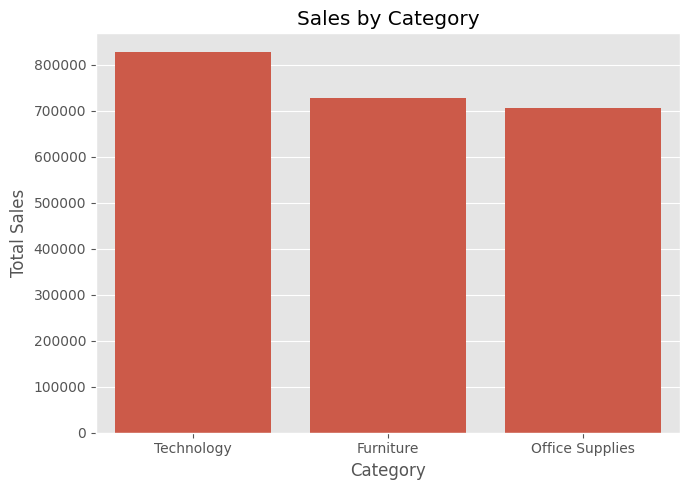

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/category_sales.png", dpi=300)

plt.show()

In [18]:
import os

print(os.getcwd())

C:\Users\sumit\OneDrive\Desktop\SalesForecasting_SumitBanerjee


In [20]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


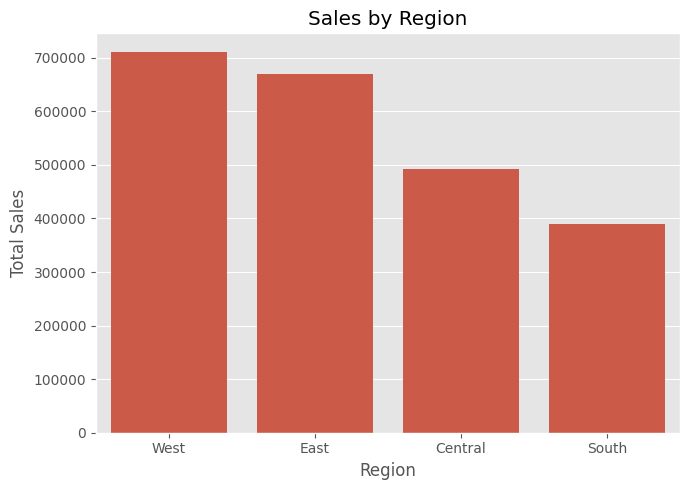

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/region_sales.png", dpi=300)

plt.show()

In [22]:
monthly_sales = (
    df.groupby("Month_Name")["Sales"]
      .sum()
)

print(monthly_sales)

Month_Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


In [23]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

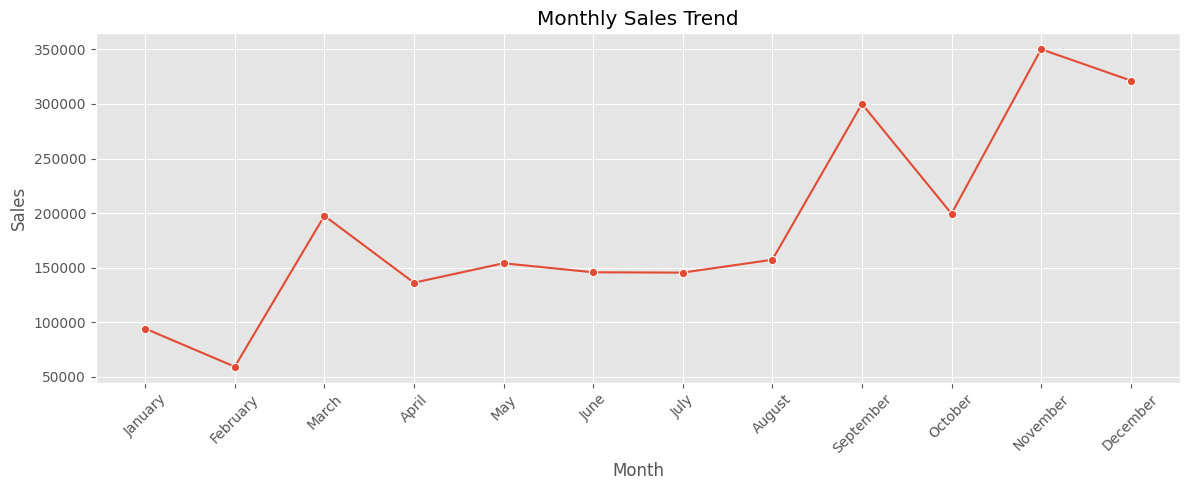

In [24]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/monthly_sales.png", dpi=300)

plt.show()

In [25]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


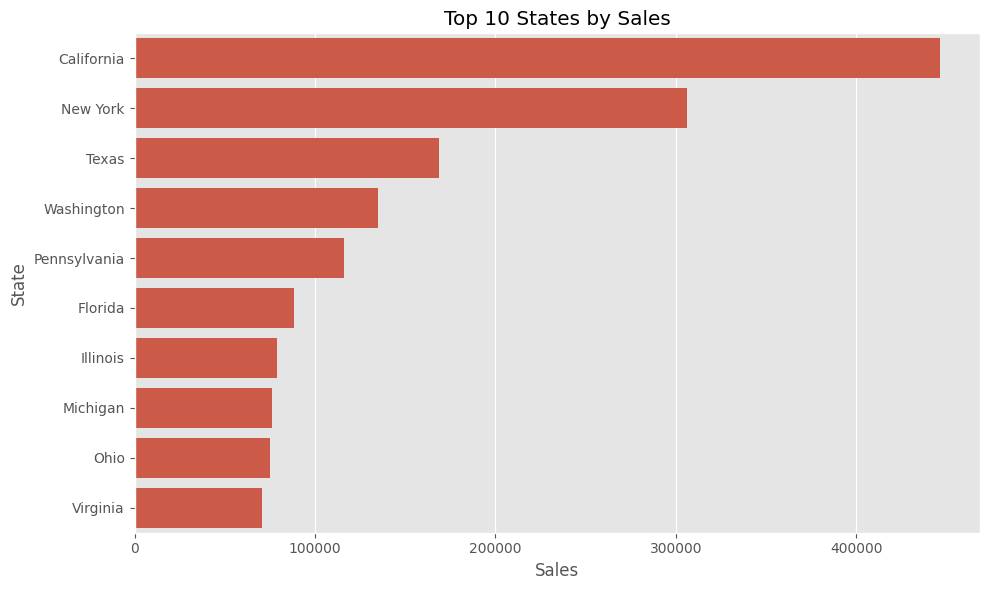

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("charts/top10_states.png", dpi=300)

plt.show()

## Observations

- The dataset contains 9,800 sales transactions with 18 columns.
- Only the Postal Code column contains 11 missing values, and no duplicate records were found.
- The average shipping time is around 4 days, with most orders delivered within 4–5 days.
- Technology is the highest revenue-generating category, followed by Furniture and Office Supplies.
- The West region generated the highest sales, while the South region recorded the lowest.
- California contributed the highest sales among all states.
- Sales increased significantly during the last quarter (October–December), with November being the best-performing month.

In [27]:
# Sales by Segment

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


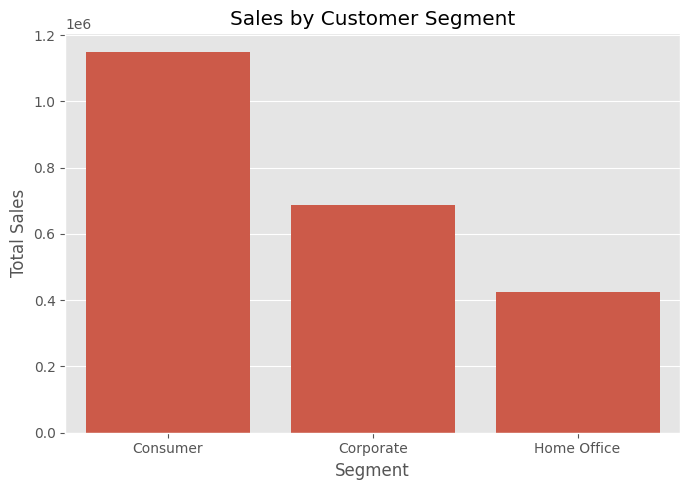

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/segment_sales.png", dpi=300)

plt.show()

In [29]:
shipmode_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(shipmode_sales)

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


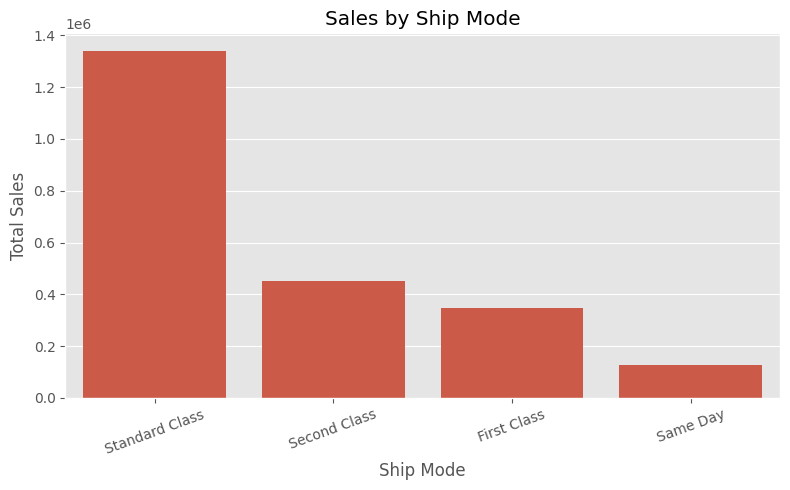

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipmode_sales.index,
    y=shipmode_sales.values
)

plt.xticks(rotation=20)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/shipmode_sales.png", dpi=300)

plt.show()

In [31]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


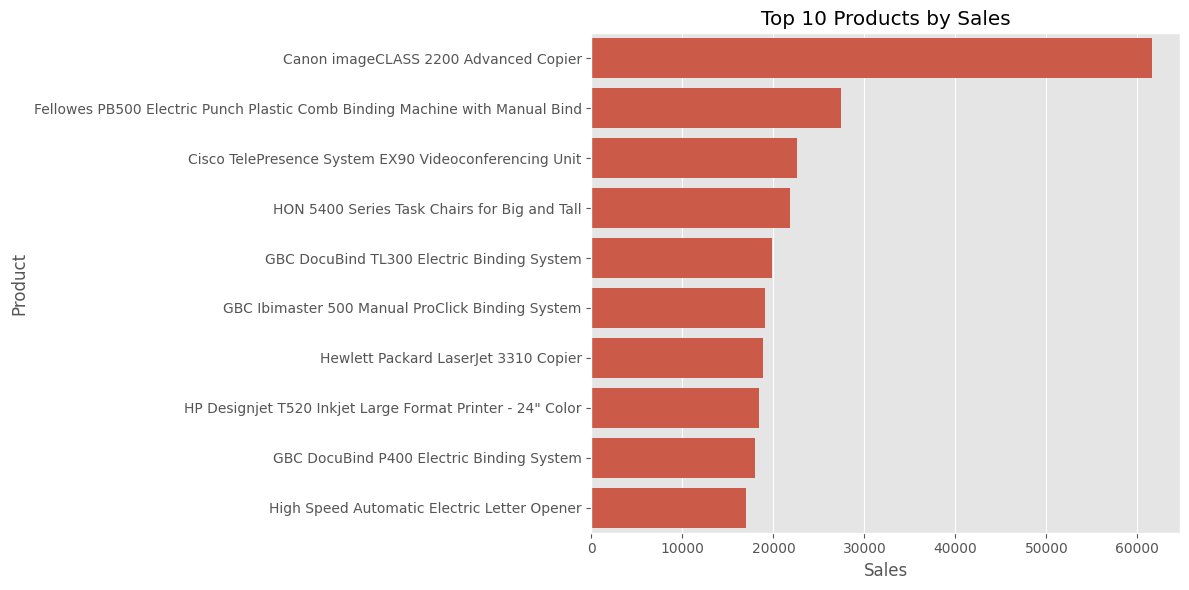

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("charts/top_products.png", dpi=300)

plt.show()

In [33]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


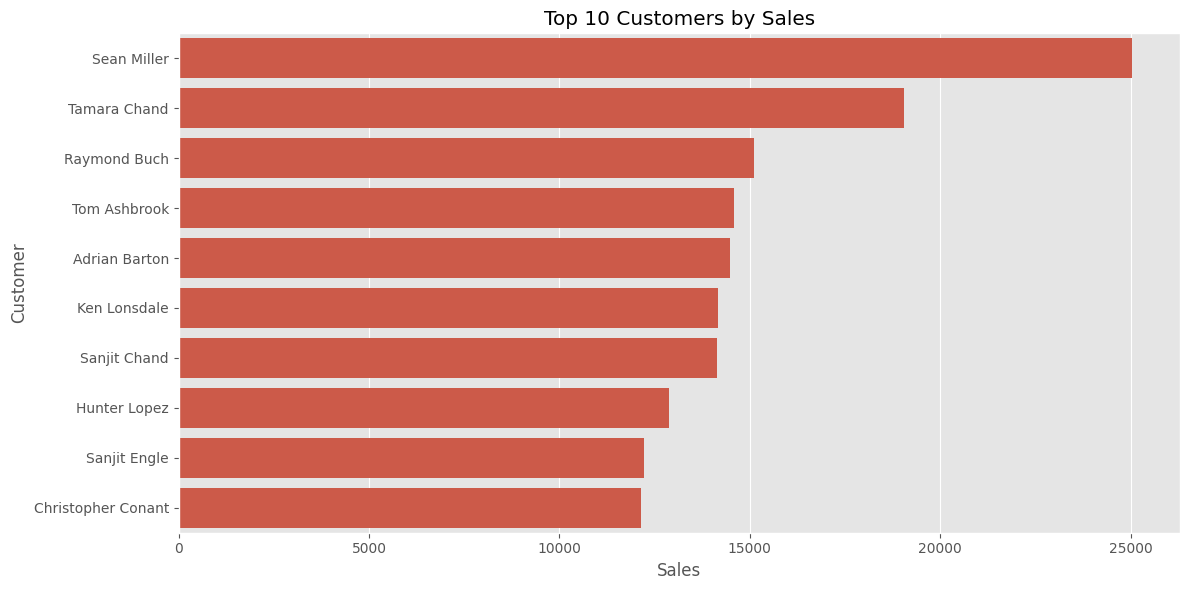

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig("charts/top_customers.png", dpi=300)

plt.show()

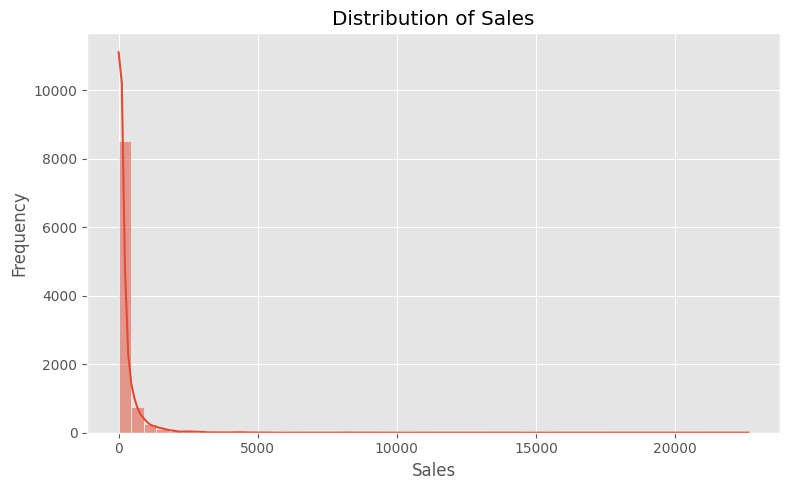

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("charts/sales_distribution.png", dpi=300)

plt.show()

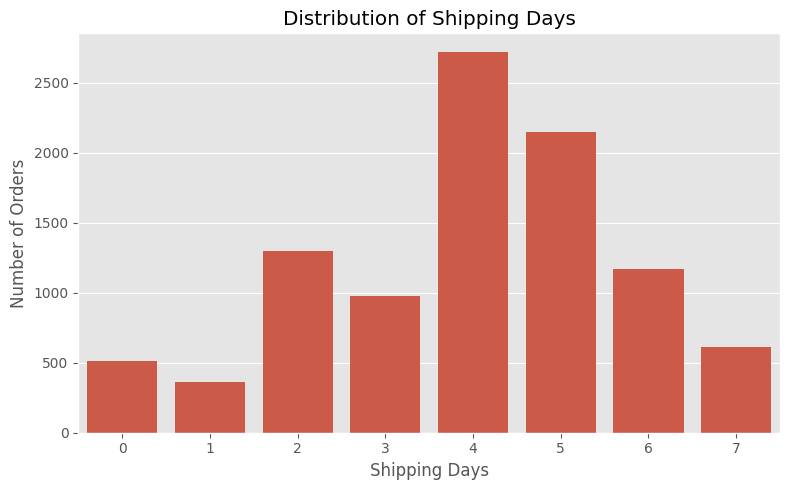

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Shipping Days"
)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("charts/shipping_days_distribution.png", dpi=300)

plt.show()

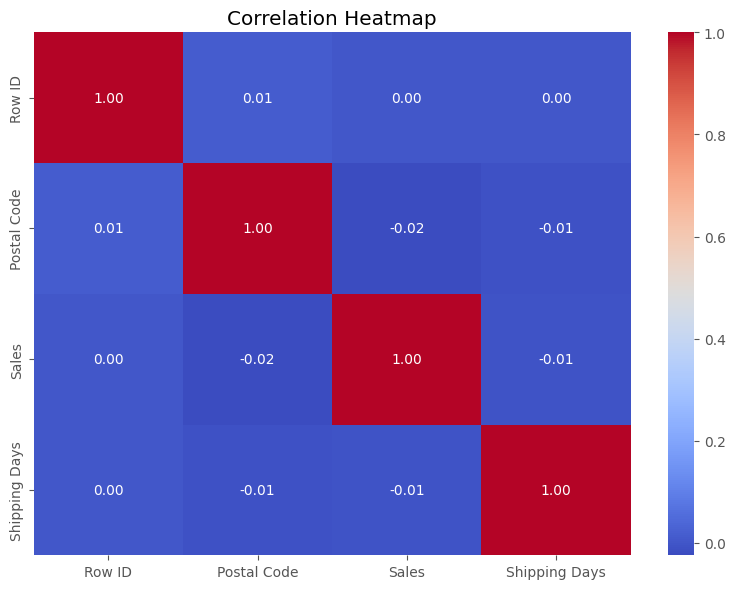

In [37]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png", dpi=300)

plt.show()

In [38]:
year_sales = (
    df.groupby("Year")["Sales"]
      .sum()
)

print(year_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


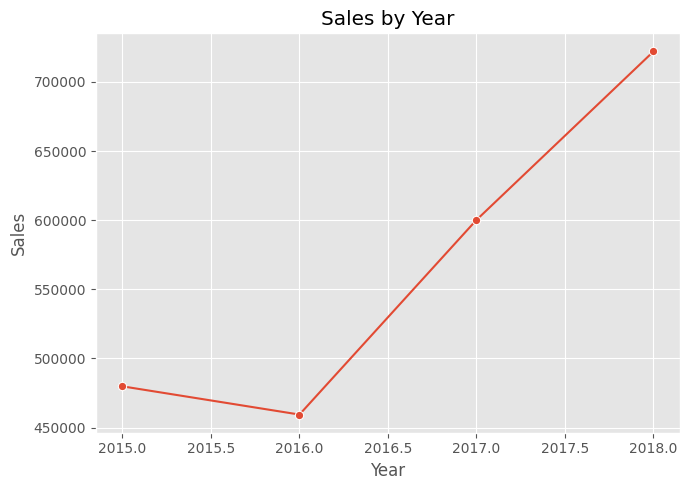

In [39]:
plt.figure(figsize=(7,5))

sns.lineplot(
    x=year_sales.index,
    y=year_sales.values,
    marker="o"
)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/year_sales.png", dpi=300)

plt.show()

## Business Insights

- Consumer customers generated the highest total sales among all customer segments.
- Standard Class was the most frequently used shipping mode and contributed the highest revenue.
- The Canon imageCLASS 2200 Advanced Copier generated the highest sales among all products.
- Sean Miller was the highest-value customer based on total purchases.
- Sales distribution is highly right-skewed, indicating that a small number of high-value orders contribute significantly to overall revenue.
- Most orders were delivered within 4 to 5 days.
- Business performance improved significantly in 2017 and reached its highest sales in 2018.

In [40]:
# Sales by Category and Region

pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

print(pivot_table.round(2))

Region             Central       East      South       West
Category                                                   
Furniture        160317.46  206461.39  116531.48  245348.25
Office Supplies  163590.24  199940.81  124424.77  217466.51
Technology       168739.21  263116.53  148195.21  247404.93


In [41]:
# Sales by Category and Region

pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

print(pivot_table.round(2))

Region             Central       East      South       West
Category                                                   
Furniture        160317.46  206461.39  116531.48  245348.25
Office Supplies  163590.24  199940.81  124424.77  217466.51
Technology       168739.21  263116.53  148195.21  247404.93


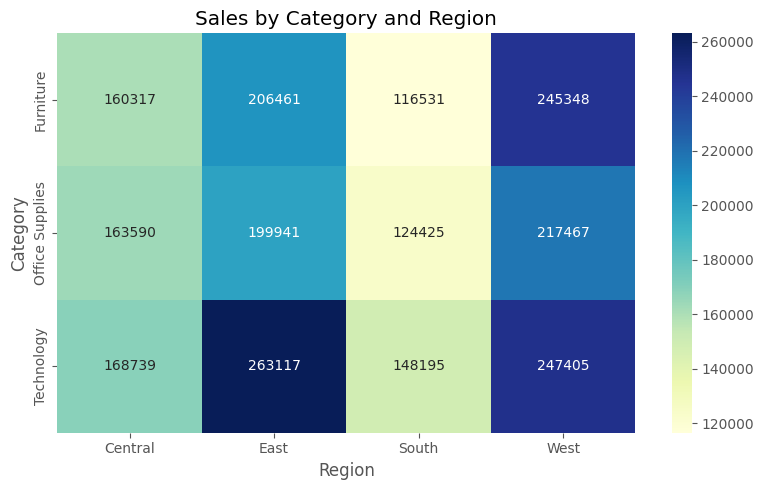

In [42]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Sales by Category and Region")

plt.tight_layout()

plt.savefig("charts/category_region_heatmap.png", dpi=300)

plt.show()

In [43]:
top_cities = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_cities)

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


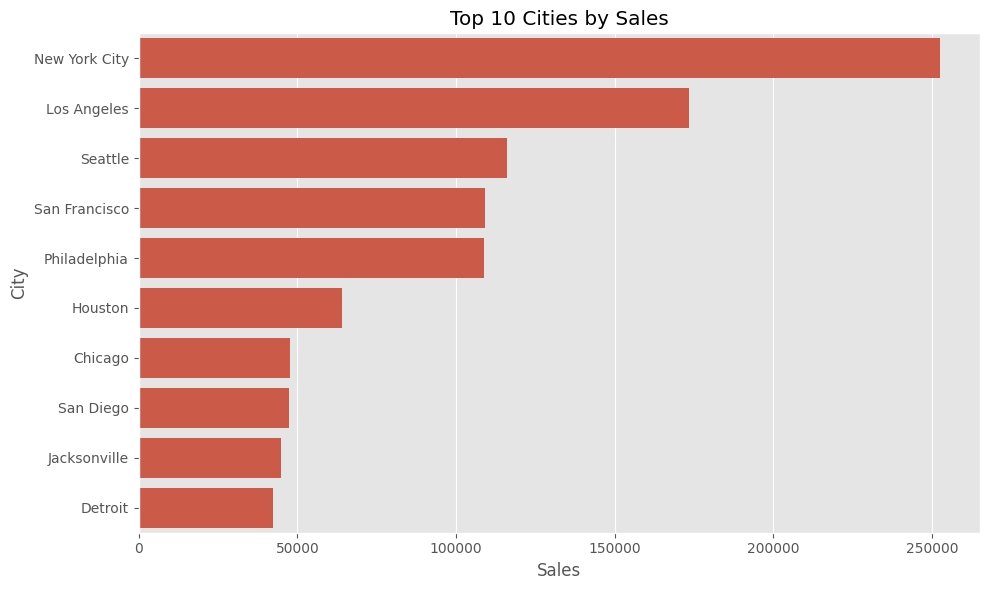

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Sales")

plt.xlabel("Sales")

plt.ylabel("City")

plt.tight_layout()

plt.savefig("charts/top_cities.png", dpi=300)

plt.show()

In [45]:
shipping_mode = (
    df.groupby("Ship Mode")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_mode.round(2))

Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.25
Standard Class    5.01
Name: Shipping Days, dtype: float64


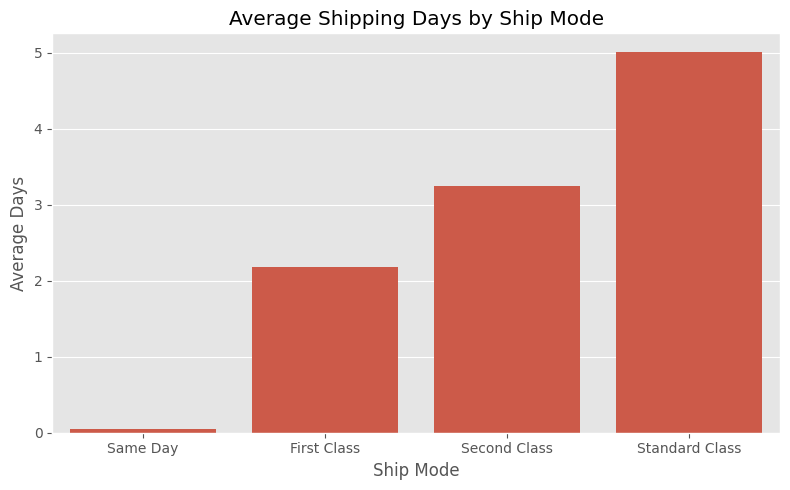

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_mode.index,
    y=shipping_mode.values
)

plt.title("Average Shipping Days by Ship Mode")

plt.xlabel("Ship Mode")

plt.ylabel("Average Days")

plt.tight_layout()

plt.savefig("charts/avg_shipping_days.png", dpi=300)

plt.show()

In [47]:
top_orders = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(top_orders)

Customer Name
Emily Phan             17
Zuschuss Carroll       13
Chloris Kastensmidt    13
Joel Eaton             13
Patrick Gardner        13
Rick Bensley           12
Sally Hughsby          12
Pete Kriz              12
Noel Staavos           12
Resi Pölking           12
Name: Order ID, dtype: int64


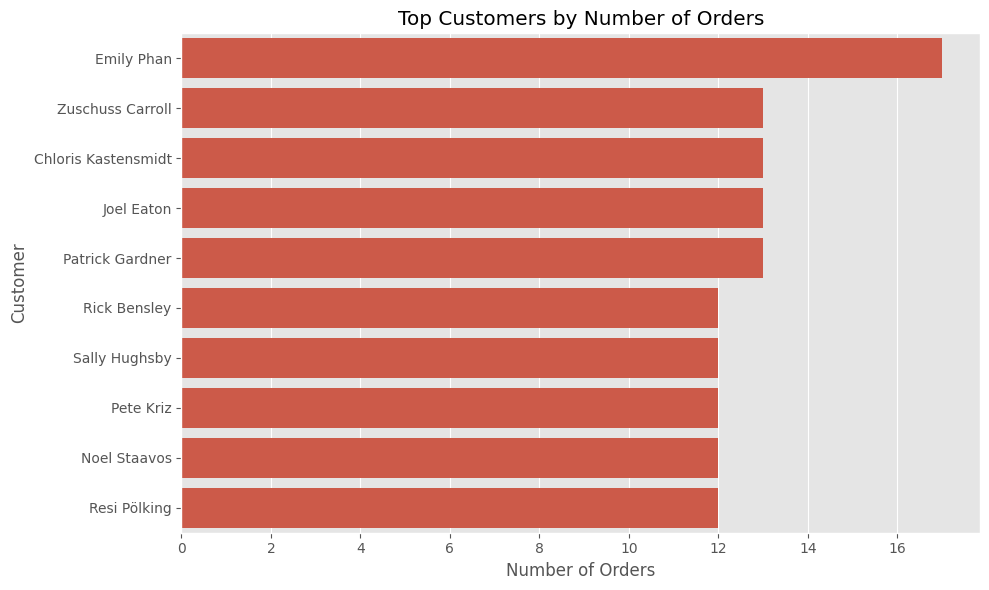

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_orders.values,
    y=top_orders.index
)

plt.title("Top Customers by Number of Orders")

plt.xlabel("Number of Orders")

plt.ylabel("Customer")

plt.tight_layout()

plt.savefig("charts/top_customer_orders.png", dpi=300)

plt.show()

In [49]:
print("="*50)

print("BUSINESS KPI SUMMARY")

print("="*50)

print(f"Total Sales           : ${df['Sales'].sum():,.2f}")

print(f"Total Orders          : {df['Order ID'].nunique()}")

print(f"Total Customers       : {df['Customer ID'].nunique()}")

print(f"Total Products        : {df['Product Name'].nunique()}")

print(f"Average Shipping Days : {df['Shipping Days'].mean():.2f}")

print(f"Average Order Value   : ${df['Sales'].mean():.2f}")

BUSINESS KPI SUMMARY
Total Sales           : $2,261,536.78
Total Orders          : 4922
Total Customers       : 793
Total Products        : 1849
Average Shipping Days : 3.96
Average Order Value   : $230.77


## Observations

- Technology products generated strong sales across multiple regions.
- California-based cities contributed significantly to total sales.
- Standard Class shipments take longer on average but handle the majority of orders.
- A small group of customers placed a large number of orders, indicating loyal repeat customers.
- The business serves thousands of unique customers and products, showing a diverse customer base.
- Overall KPIs indicate healthy sales performance with consistent customer activity.

In [50]:
# Sales by Sub-Category

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(subcategory_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


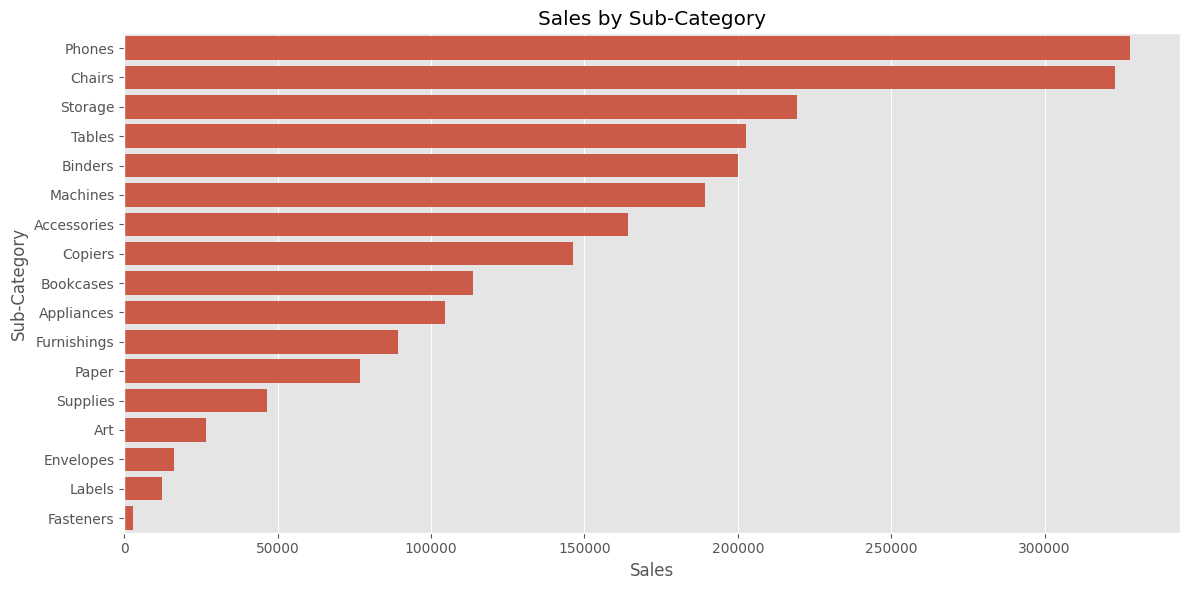

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()

plt.savefig("charts/subcategory_sales.png", dpi=300)

plt.show()

In [52]:
# Average Sales by Category

avg_category_sales = (
    df.groupby("Category")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_category_sales)

Category
Technology         456.401474
Furniture          350.653790
Office Supplies    119.381001
Name: Sales, dtype: float64


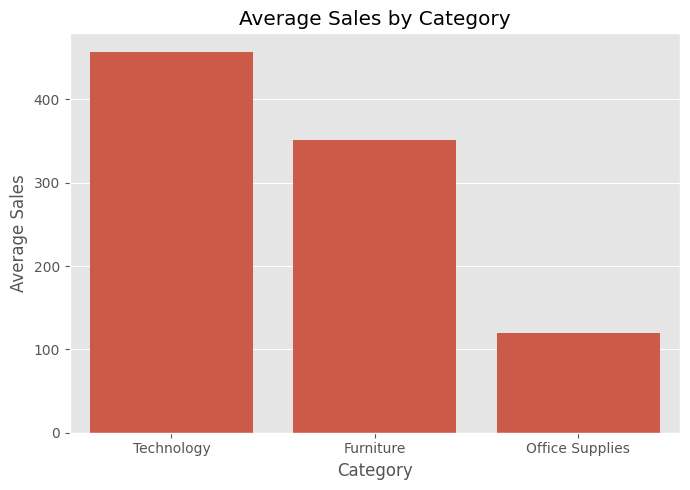

In [53]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=avg_category_sales.index,
    y=avg_category_sales.values
)

plt.title("Average Sales by Category")
plt.xlabel("Category")
plt.ylabel("Average Sales")

plt.tight_layout()

plt.savefig("charts/average_category_sales.png", dpi=300)

plt.show()

In [54]:
# Number of Orders by Region

orders_region = (
    df.groupby("Region")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
)

print(orders_region)

Region
West       1587
East       1369
Central    1156
South       810
Name: Order ID, dtype: int64


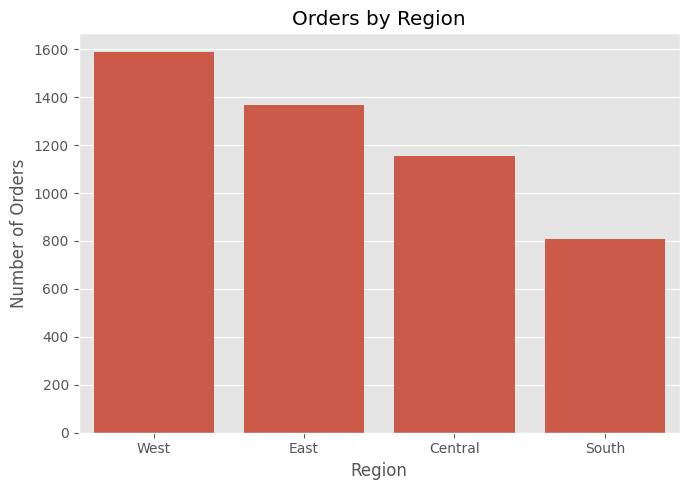

In [55]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=orders_region.index,
    y=orders_region.values
)

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("charts/orders_region.png", dpi=300)

plt.show()

In [56]:
# Top Product Category in each Region

region_category = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

print(region_category.round(2))

Category  Furniture  Office Supplies  Technology
Region                                          
Central   160317.46        163590.24   168739.21
East      206461.39        199940.81   263116.53
South     116531.48        124424.77   148195.21
West      245348.25        217466.51   247404.93


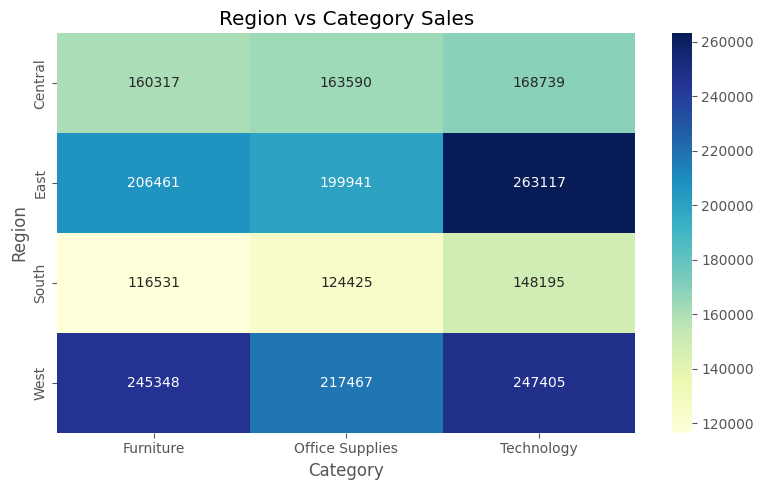

In [57]:
plt.figure(figsize=(8,5))

sns.heatmap(
    region_category,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Region vs Category Sales")

plt.tight_layout()

plt.savefig("charts/region_category_heatmap.png", dpi=300)

plt.show()

In [58]:
day_sales = (
    df.groupby("Day")["Sales"]
      .sum()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

print(day_sales)

Day
Monday       348791.5516
Tuesday      420535.9243
Wednesday    315888.9722
Thursday     142839.2402
Friday       234710.8402
Saturday     420901.4763
Sunday       377868.7779
Name: Sales, dtype: float64


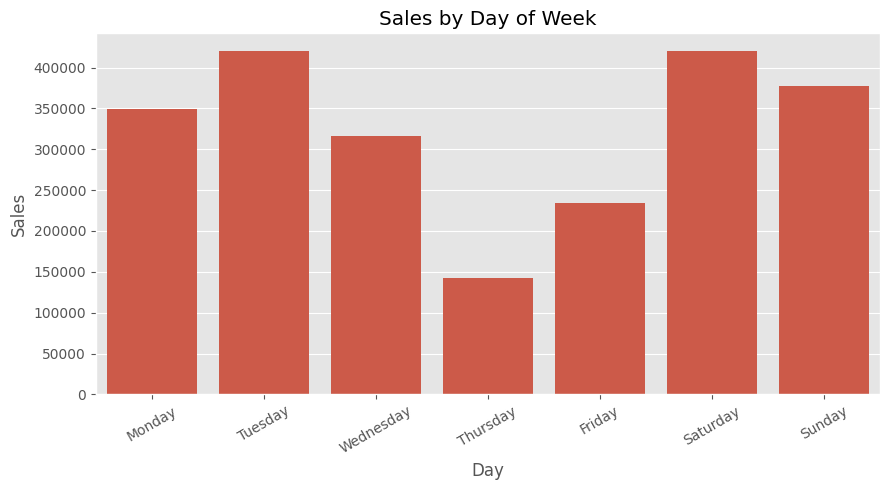

In [59]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.xticks(rotation=30)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/day_sales.png", dpi=300)

plt.show()

In [61]:
print("""
================ OBSERVATIONS ================

Phones generated the highest sales among all sub-categories.

Technology products recorded the highest average sales per order.

The West region generated the highest number of customer orders.

Tuesday and Saturday recorded the highest total sales.

The South region consistently showed lower sales across all product categories.

====================================================
""")


================ OBSERVATIONS ================

Phones generated the highest sales among all sub-categories.

Technology products recorded the highest average sales per order.

The West region generated the highest number of customer orders.

Tuesday and Saturday recorded the highest total sales.

The South region consistently showed lower sales across all product categories.




In [62]:
print("="*60)
print("          EXECUTIVE BUSINESS DASHBOARD")
print("="*60)

print(f"Total Sales           : ${df['Sales'].sum():,.2f}")

print(f"Average Sales         : ${df['Sales'].mean():,.2f}")

print(f"Total Orders          : {df['Order ID'].nunique()}")

print(f"Total Customers       : {df['Customer ID'].nunique()}")

print(f"Total Products        : {df['Product Name'].nunique()}")

print(f"Average Shipping Days : {df['Shipping Days'].mean():.2f}")

print("="*60)

          EXECUTIVE BUSINESS DASHBOARD
Total Sales           : $2,261,536.78
Average Sales         : $230.77
Total Orders          : 4922
Total Customers       : 793
Total Products        : 1849
Average Shipping Days : 3.96


In [63]:
best_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .idxmax()
)

best_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .max()
)

print("Best Performing Category")
print("------------------------")
print(best_category)
print(f"Sales : ${best_sales:,.2f}")

Best Performing Category
------------------------
Technology
Sales : $827,455.87


In [64]:
best_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .idxmax()
)

best_region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .max()
)

print("Best Performing Region")
print("----------------------")
print(best_region)
print(f"Sales : ${best_region_sales:,.2f}")

Best Performing Region
----------------------
West
Sales : $710,219.68


In [65]:
best_month = monthly_sales.idxmax()

best_month_sales = monthly_sales.max()

print("Best Sales Month")
print("----------------")
print(best_month)
print(f"Sales : ${best_month_sales:,.2f}")

Best Sales Month
----------------
November
Sales : $350,161.71


In [66]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
)

best_customer = customer_sales.idxmax()

best_customer_sales = customer_sales.max()

print("Top Customer")
print("------------")
print(best_customer)
print(f"Sales : ${best_customer_sales:,.2f}")

Top Customer
------------
Sean Miller
Sales : $25,043.05


In [67]:
print("""
================ BUSINESS RECOMMENDATIONS ================

1. Increase inventory for Technology products because they generate the highest revenue.

2. Promote high-demand Sub-Categories such as Phones and Chairs.

3. Improve marketing campaigns in the South region to increase sales.

4. Offer loyalty rewards to high-value customers.

5. Encourage faster shipping methods to improve customer satisfaction.

6. Launch promotional campaigns during lower-performing weekdays.

==========================================================
""")


================ BUSINESS RECOMMENDATIONS ================

1. Increase inventory for Technology products because they generate the highest revenue.

2. Promote high-demand Sub-Categories such as Phones and Chairs.

3. Improve marketing campaigns in the South region to increase sales.

4. Offer loyalty rewards to high-value customers.

5. Encourage faster shipping methods to improve customer satisfaction.

6. Launch promotional campaigns during lower-performing weekdays.




In [68]:
print("""
================ EXECUTIVE SUMMARY ================

This Superstore Sales Analysis project analyzed 9,800 customer orders
to identify business trends, customer behavior, regional performance,
and product sales.

Key findings include:

• Technology generated the highest revenue.
• Phones were the best-selling sub-category.
• West region contributed the highest sales.
• Tuesday and Saturday recorded peak sales.
• Standard Class was the most frequently used shipping mode.
• A small number of customers generated a significant portion of revenue.

These insights can help management improve inventory planning,
marketing strategy, customer retention, and regional sales performance.

==================================================
""")


================ EXECUTIVE SUMMARY ================

This Superstore Sales Analysis project analyzed 9,800 customer orders
to identify business trends, customer behavior, regional performance,
and product sales.

Key findings include:

• Technology generated the highest revenue.
• Phones were the best-selling sub-category.
• West region contributed the highest sales.
• Tuesday and Saturday recorded peak sales.
• Standard Class was the most frequently used shipping mode.
• A small number of customers generated a significant portion of revenue.

These insights can help management improve inventory planning,
marketing strategy, customer retention, and regional sales performance.




In [69]:
df.to_csv("clean_superstore_dataset.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [70]:
print("="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY 🎉")
print("="*70)

print("""
Project Name :
Superstore Sales Analysis

Tools Used:
Python
Pandas
NumPy
Matplotlib
Seaborn

Dataset:
9800 Orders

Visualizations:
20+ Charts

Business KPIs:
Completed

Executive Summary:
Completed

GitHub Ready:
YES

Submission Ready:
YES
""")

print("="*70)

🎉 PROJECT COMPLETED SUCCESSFULLY 🎉

Project Name :
Superstore Sales Analysis

Tools Used:
Python
Pandas
NumPy
Matplotlib
Seaborn

Dataset:
9800 Orders

Visualizations:
20+ Charts

Business KPIs:
Completed

Executive Summary:
Completed

GitHub Ready:
YES

Submission Ready:
YES

